# Лекція 4 - Геометрія високовимірних даних


**Курс:** Машинне навчання. Частина 2  
**Тиждень:** 7  
**Тема лекції:** Геометрія високовимірних даних

## Цілі лекції

1. [Прокляття розмірності](#curse) - що відбувається з даними у великовимірному просторі  
2. [Переваги зменшення розмірності](#advantages) - навіщо це потрібно  
3. [Вибір рис (Feature Selection)](#selection) - фільтрація, обгортка, вбудовані методи  
4. [Видобування рис (Feature Extraction)](#extraction) - перехід до нового простору  
5. [Метод головних компонент (PCA)](#pca) - геометрія, математика, алгоритм  
6. [Сингулярний розклад (SVD)](#svd) - матрична факторизація та зв'язок із PCA  
7. [Лінійний дискримінантний аналіз (LDA)](#lda) - контрольоване зменшення розмірності  
8. [Порівняння методів](#comparison) - як обирати підхід

## Налаштування середовища

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Jupyter display
%matplotlib inline

# Reproducibility
np.random.seed(42)

# Add course modules to path
import sys
from pathlib import Path

course_root = Path.cwd()
if 'course' in course_root.parts:
    while course_root.name != 'course' and course_root.parent != course_root:
        course_root = course_root.parent
else:
    course_root = course_root / 'course'

modules_path = course_root / 'modules'
if str(modules_path) not in sys.path:
    sys.path.insert(0, str(modules_path))

# Apply shared colorblind-safe plot style
from plot_style import setup_plot_style, COLORBLIND_PALETTE
setup_plot_style()

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import make_classification, load_iris, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import (VarianceThreshold, SelectKBest,
                                       f_classif, mutual_info_classif,
                                       RFE, SequentialFeatureSelector)
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Color palette used throughout this notebook
COLORS = ["#2C7BB6", "#D7191C", "#1A9641", "#FDAE61", "#762A83"]


---
<a id='curse'></a>
## 1. Прокляття розмірності

**Прокляття розмірності** (curse of dimensionality) - термін, що описує сукупність проблем,
які виникають при роботі з даними у великовимірному просторі.

### 1.1 Основні ефекти

| Ефект | Пояснення |
|---|---|
| Розрідженість даних | Точки стають дедалі більш віддаленими одна від одної |
| Потреба в більших вибірках | Для покриття простору потрібно експоненційно більше прикладів |
| Деградація відстаней | Евклідова відстань втрачає сенс у великовимірному просторі |
| Перенавчання | Більше ознак $\Rightarrow$ складніша модель $\Rightarrow$ легше перенавчитись |

### 1.2 Геометричний аргумент

Розглянемо одиничний гіперкуб $[0,1]^d$. Яку частку об'єму займає куля, вписана в нього?

$$\text{Ratio}(d) = \frac{V_{\text{ball}}(d)}{V_{\text{cube}}(d)} = \frac{\pi^{d/2} / \Gamma(d/2+1)}{1^d}$$

З ростом $d$ ця частка прямує до **нуля**: простір стає переважно «кутовим», тобто майже весь об'єм гіперкуба зосереджений поблизу його ребер, а не центру.

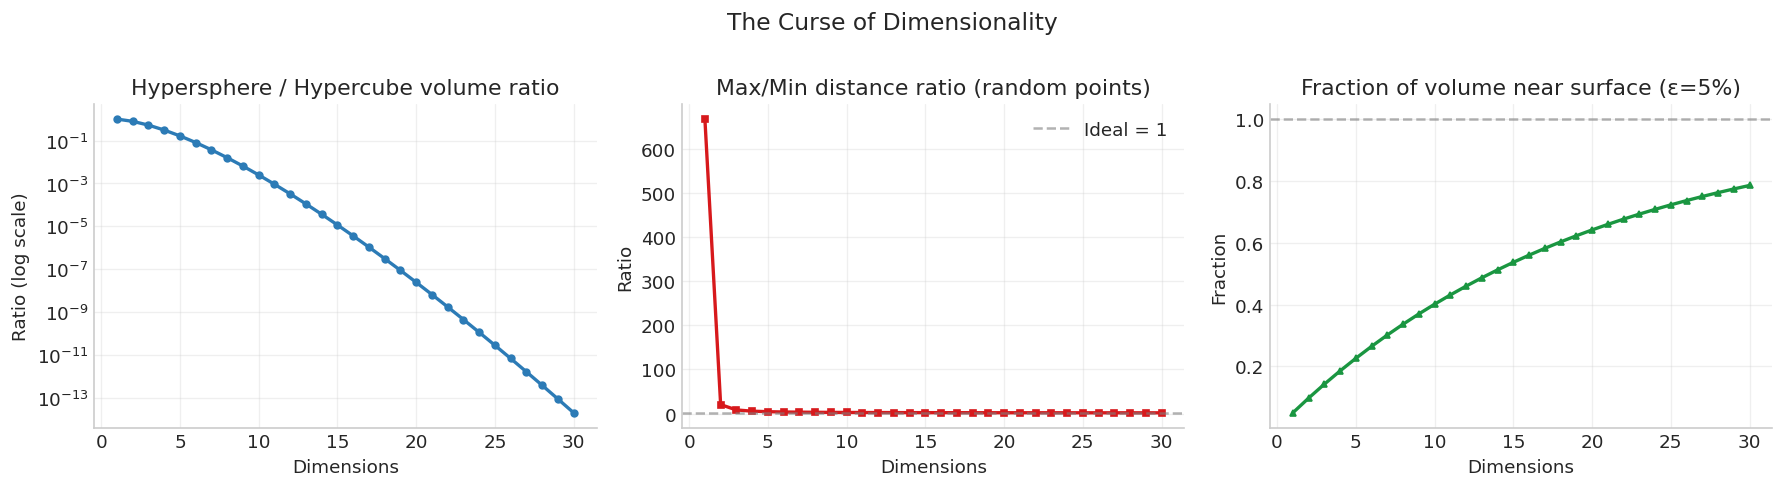

Left: the hypersphere shrinks relative to the cube - most volume is in corners.
Middle: max and min distances converge, making NN-search meaningless.
Right: at high d, nearly all points lie near the surface of the ball.


In [2]:
# --------------------------------------------------------------------------
# 1a. Fraction of the hypercube volume occupied by an inscribed hypersphere
# --------------------------------------------------------------------------
from scipy.special import gamma

def ball_volume_ratio(d):
    """Ratio of d-ball volume to d-hypercube volume (unit side / unit radius)."""
    ball_vol = (np.pi ** (d / 2)) / gamma(d / 2 + 1)   # volume of unit d-ball
    cube_vol = 2 ** d                                    # volume of cube with side 2
    return ball_vol / cube_vol

dims = np.arange(1, 31)
ratios = [ball_volume_ratio(d) for d in dims]

# --------------------------------------------------------------------------
# 1b. Nearest / farthest neighbour distance ratio as dimensionality grows
# --------------------------------------------------------------------------
def distance_ratio(n_samples=500, n_reps=30):
    """Mean ratio max/min pairwise distance for random uniform points."""
    ratios = []
    for d in dims:
        rep_ratios = []
        for _ in range(n_reps):
            pts = np.random.rand(n_samples, d)
            # Use a small subsample to speed things up
            subset = pts[:50]
            dists = np.sqrt(((subset[:, None] - subset[None]) ** 2).sum(-1))
            np.fill_diagonal(dists, np.inf)
            min_d = dists.min(axis=1)
            np.fill_diagonal(dists, 0)
            max_d = dists.max(axis=1)
            rep_ratios.append(np.mean(max_d / (min_d + 1e-12)))
        ratios.append(np.mean(rep_ratios))
    return ratios

dist_ratios = distance_ratio()

# --------------------------------------------------------------------------
# 1c. Fraction of points near the surface of a unit hypersphere
# --------------------------------------------------------------------------
def surface_fraction(d, epsilon=0.05):
    """Fraction of ball volume within epsilon of the surface (shell)."""
    return 1 - (1 - epsilon) ** d

surface_fracs = [surface_fraction(d) for d in dims]

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogy(dims, ratios, color=COLORS[0], lw=2, marker='o', markersize=4)
axes[0].set_title("Hypersphere / Hypercube volume ratio")
axes[0].set_xlabel("Dimensions"); axes[0].set_ylabel("Ratio (log scale)")
axes[0].grid(alpha=0.3)

axes[1].plot(dims, dist_ratios, color=COLORS[1], lw=2, marker='s', markersize=4)
axes[1].set_title("Max/Min distance ratio (random points)")
axes[1].set_xlabel("Dimensions"); axes[1].set_ylabel("Ratio")
axes[1].axhline(1, linestyle='--', color='gray', alpha=0.6, label="Ideal = 1")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(dims, surface_fracs, color=COLORS[2], lw=2, marker='^', markersize=4)
axes[2].set_title("Fraction of volume near surface (ε=5%)")
axes[2].set_xlabel("Dimensions"); axes[2].set_ylabel("Fraction")
axes[2].axhline(1, linestyle='--', color='gray', alpha=0.6)
axes[2].grid(alpha=0.3)

plt.suptitle("The Curse of Dimensionality", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print("Left: the hypersphere shrinks relative to the cube - most volume is in corners.")
print("Middle: max and min distances converge, making NN-search meaningless.")
print("Right: at high d, nearly all points lie near the surface of the ball.")

### Підсумок

- **Ліворуч** - частка об'єму гіперсфери відносно гіперкуба стрімко прямує до нуля: вже при $d \approx 10$ вона практично нульова; весь об'єм зосереджений у «кутах» простору.
- **По центру** - відношення максимальної до мінімальної відстані між точками наближається до 1: відстані стають нерозрізненними, що знецінює алгоритми, засновані на відстані (KNN, k-means).
- **Праворуч** - частка точок поблизу поверхні кулі сягає ~100% уже при $d \approx 20$: у великовимірному просторі дані «витісняються» на периферію.

**Практичний висновок:** зі зростанням кількості ознак дані стають дедалі розрідженішими, метрики відстані деградують, а для покриття простору потрібно експоненційно більше прикладів. Це пряма мотивація для зменшення розмірності.

---
<a id='advantages'></a>
## 2. Переваги зменшення розмірності

Зменшення розмірності вирішує одразу кілька проблем:

* **Менше шуму та надлишкових ознак** - покращується якість моделі.
* **Скорочення пам'яті та часу навчання** - менший розмір даних.
* **Кращі умови для алгоритмів** - частина методів некоректно працює у великовимірному просторі (наприклад, KNN).
* **Можливість візуалізації** - можна відобразити дані у 2D/3D для аналізу.

### Два напрями

```
Зменшення розмірності
├── Вибір рис (Feature Selection)   ← залишаємо підмножину оригінальних ознак
└── Видобування рис (Feature Extraction) ← будуємо нові ознаки (комбінації оригінальних)
```

---
<a id='selection'></a>
## 3. Вибір рис (Feature Selection)

Мета: відібрати найбільш **інформативну підмножину** оригінальних ознак, не змінюючи їх природи.

$$X \in \mathbb{R}^{n \times d} \;\xrightarrow{\text{selection}}\; X_{\text{sel}} \in \mathbb{R}^{n \times k}, \quad k < d$$

Три стратегії: **фільтрація**, **обгортка**, **вбудовані методи**.

### 3.1 Фільтруючі методи (Filter)

Оцінюють ознаки **незалежно від моделі**, використовуючи статистичні критерії.
Обчислювально дешеві - підходять для тисяч ознак.

| Метод | Критерій | Тип задачі | Коментар |
|---|---|---|---|
| Variance Threshold | Дисперсія ознаки | Будь-яка | Видаляє майже константні ознаки - вони несуть мало інформації незалежно від задачі. Застосовувати **до** масштабування. |
| Pearson / Spearman | Кореляція з цільовою | Регресія | Pearson - лінійний зв'язок; Spearman - монотонний (стійкий до викидів). Не виявляє нелінійних залежностей. |
| Mutual Information | $I(X_j; y)$ - взаємна інформація | Класифікація / Регресія | Вимірює, скільки інформації про мітку несе ознака. Вловлює **будь-які** залежності, зокрема нелінійні. |
| Chi-squared | $\chi^2$ критерій незалежності | Класифікація (категоріальна) | Перевіряє, чи частоти значень ознаки залежать від класу. Тільки для **невід'ємних** дискретних ознак. |
| ANOVA F-test | Дисперсійний аналіз | Класифікація (числова) | Порівнює середні значення ознаки між класами. Чим більше $F$, тим краще ознака розрізняє класи. Передбачає нормальність. |

**Перевага:** швидко.  
**Недолік:** не враховує взаємодію між ознаками.

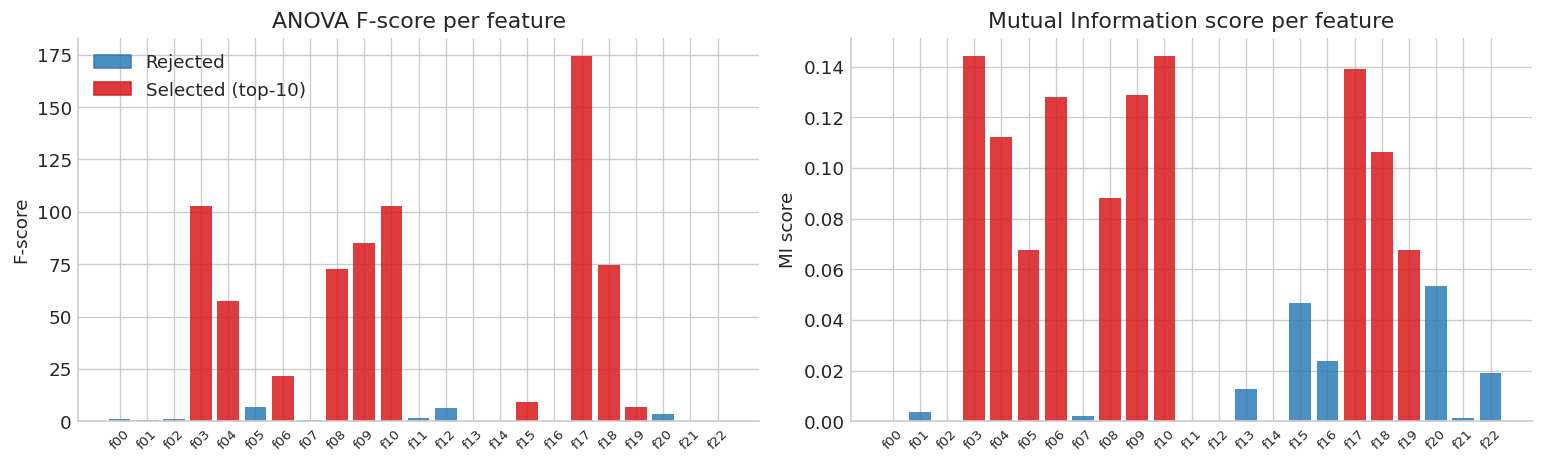

Low-variance features removed by VarianceThreshold(threshold=0.5) on raw data: ['f20', 'f21', 'f22']


In [3]:
# --------------------------------------------------------------------------
# 3.1 Filter methods demonstration on a synthetic dataset
# --------------------------------------------------------------------------
X_base, y = make_classification(
    n_samples=500, n_features=20, n_informative=5, n_redundant=5,
    n_repeated=2, random_state=RANDOM_STATE
)

# Add near-constant features to make the VarianceThreshold demo meaningful
rng = np.random.default_rng(RANDOM_STATE)
near_const = rng.normal(0, 0.05, size=(X_base.shape[0], 3))  # var ≈ 0.0025 << 0.5
X = np.hstack([X_base, near_const])
feature_names = [f"f{i:02d}" for i in range(X.shape[1])]

# ── Variance Threshold (MUST run on raw data, before any scaling) ─────────────
# After StandardScaler every feature has variance = 1.0, so no feature would
# ever be removed by VarianceThreshold - the filter only makes sense on the
# original scale.
vt = VarianceThreshold(threshold=0.5)
vt.fit(X)
low_var_mask = ~vt.get_support()

# Scale for the statistical-score methods below
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── ANOVA F-test ─────────────────────────────────────────────────────────────
selector_f = SelectKBest(f_classif, k=10)
selector_f.fit(X_scaled, y)
f_scores = selector_f.scores_

# ── Mutual Information ────────────────────────────────────────────────────────
selector_mi = SelectKBest(mutual_info_classif, k=10)
selector_mi.fit(X_scaled, y)
mi_scores = selector_mi.scores_

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x_pos = np.arange(len(feature_names))

axes[0].bar(x_pos, f_scores, color=[COLORS[1] if m else COLORS[0]
            for m in selector_f.get_support()], alpha=0.85)
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(feature_names, rotation=45, fontsize=8)
axes[0].set_title("ANOVA F-score per feature"); axes[0].set_ylabel("F-score")
axes[0].legend(handles=[
    plt.Rectangle((0,0),1,1, color=COLORS[0], alpha=0.85, label="Rejected"),
    plt.Rectangle((0,0),1,1, color=COLORS[1], alpha=0.85, label="Selected (top-10)")
])

axes[1].bar(x_pos, mi_scores, color=[COLORS[1] if m else COLORS[0]
            for m in selector_mi.get_support()], alpha=0.85)
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(feature_names, rotation=45, fontsize=8)
axes[1].set_title("Mutual Information score per feature"); axes[1].set_ylabel("MI score")

plt.tight_layout()
plt.show()
print(f"Low-variance features removed by VarianceThreshold(threshold=0.5) on raw data: "
      f"{[feature_names[i] for i, m in enumerate(low_var_mask) if m]}")

### Підсумок
- **ANOVA F-score** та **взаємна інформація (MI)** виявляють схожий набір найважливіших ознак, проте ранжування може відрізнятись: ANOVA вимірює лінійну залежність між ознакою та міткою, MI - будь-яку (зокрема нелінійну).
- Штучно додані майже константні ознаки (дисперсія ≈ 0.0025) отримують низькі бали і правильно відкидаються `VarianceThreshold` на сирих даних - це підтверджує необхідність застосовувати цей фільтр **до** масштабування.
- Фільтруючі методи є швидким і масштабованим першим кроком у відборі ознак, але **не враховують взаємодію між ознаками** - це обмеження усувають методи-обгортки та вбудовані методи.

### 3.2 Методи обгортки (Wrapper)

Оцінюють підмножини ознак **через продуктивність конкретної моделі**.  
Вибирають підмножину, що дає найкращий результат.

| Стратегія | Принцип |
|---|---|
| **Forward Selection** | Починаємо без ознак, додаємо по одній найкращій |
| **Backward Elimination** | Починаємо з усіх ознак, прибираємо найменш важливу |
| **Bidirectional Search** | Одночасно forward та backward |
| **Exhaustive Search** | Перебір усіх $2^d$ підмножин (дорого!) |

**Перевага:** враховує взаємодію між ознаками.  
**Недолік:** обчислювально затратно (багато навчань моделі).

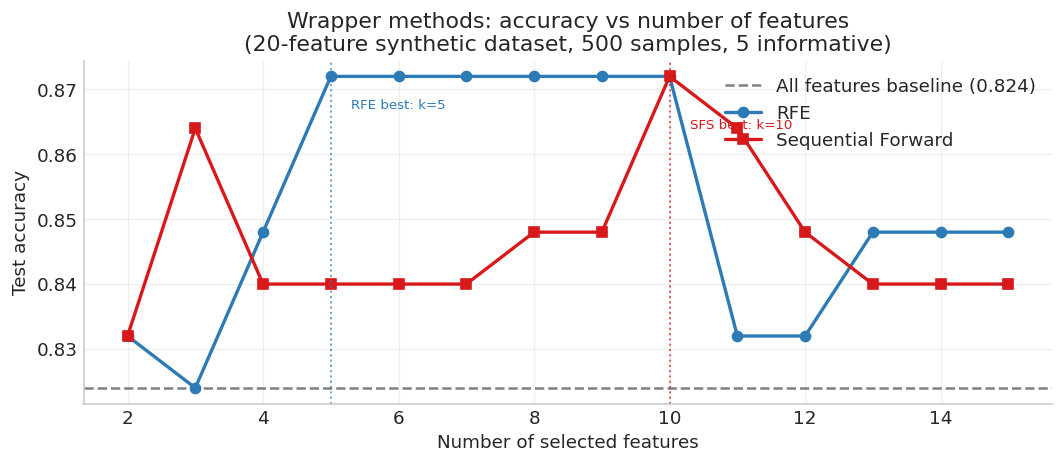

In [4]:
# --------------------------------------------------------------------------
# 3.2 Wrapper: Recursive Feature Elimination (RFE) vs Sequential Forward Selection
# --------------------------------------------------------------------------
base_model = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y, test_size=0.25, random_state=RANDOM_STATE)

k_values = list(range(2, 16))
rfe_scores, sfs_scores = [], []

for k in k_values:
    # Recursive Feature Elimination
    rfe = RFE(base_model, n_features_to_select=k)
    rfe.fit(X_tr, y_tr)
    rfe_scores.append(accuracy_score(y_te, rfe.predict(X_te)))

    # Sequential Forward Selection (greedy, cv=3)
    sfs = SequentialFeatureSelector(
        LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
        n_features_to_select=k, direction='forward', cv=3
    )
    sfs.fit(X_tr, y_tr)
    clf_sfs = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)
    clf_sfs.fit(sfs.transform(X_tr), y_tr)
    sfs_scores.append(accuracy_score(y_te, clf_sfs.predict(sfs.transform(X_te))))

fig, ax = plt.subplots(figsize=(9, 4))

# Baseline: logistic regression on all features
clf_base = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)
clf_base.fit(X_tr, y_tr)
baseline_acc = accuracy_score(y_te, clf_base.predict(X_te))

ax.axhline(baseline_acc, color='gray', linestyle='--', lw=1.5,
           label=f'All features baseline ({baseline_acc:.3f})')

ax.plot(k_values, rfe_scores, marker='o', color=COLORS[0], label='RFE', lw=2)
ax.plot(k_values, sfs_scores, marker='s', color=COLORS[1],
        label='Sequential Forward', lw=2)

# Annotate optimal k for each method
best_rfe_k = k_values[np.argmax(rfe_scores)]
best_sfs_k = k_values[np.argmax(sfs_scores)]
ax.axvline(best_rfe_k, color=COLORS[0], linestyle=':', lw=1.2, alpha=0.7)
ax.axvline(best_sfs_k, color=COLORS[1], linestyle=':', lw=1.2, alpha=0.7)
ax.annotate(f'RFE best: k={best_rfe_k}', xy=(best_rfe_k, max(rfe_scores)),
            xytext=(best_rfe_k + 0.3, max(rfe_scores) - 0.005),
            fontsize=8, color=COLORS[0])
ax.annotate(f'SFS best: k={best_sfs_k}', xy=(best_sfs_k, max(sfs_scores)),
            xytext=(best_sfs_k + 0.3, max(sfs_scores) - 0.008),
            fontsize=8, color=COLORS[1])

ax.set_xlabel("Number of selected features")
ax.set_ylabel("Test accuracy")
ax.set_title("Wrapper methods: accuracy vs number of features\n"
             "(20-feature synthetic dataset, 500 samples, 5 informative)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Підсумок

- Обидва методи - **RFE** та **Sequential Forward Selection** - демонструють зростання точності зі збільшенням $k$ до певного оптимуму, після якого вона стабілізується або дещо знижується.
- Горизонтальна лінія «All features baseline» ілюструє, що відбір підмножини ознак може давати **рівну або кращу** точність ніж навчання на всіх ознаках - завдяки видаленню шумових і надлишкових ознак.
- RFE і SFS можуть обирати **різні оптимальні підмножини**, оскільки використовують протилежні стратегії: «від більшого до меншого» та «від меншого до більшого» відповідно.
- Основний недолік методів-обгорток - **обчислювальна вартість**: для кожного $k$ необхідно кілька повторних навчань моделі.

### 3.3 Вбудовані методи (Embedded)

Відбір ознак відбувається **разом із навчанням моделі** - не потрібен окремий крок оцінки.

**L1-регуляризація (Lasso)** - додає штраф пропорційний $\|\mathbf{w}\|_1$, що змушує
коефіцієнти нерелевантних ознак обнулятись точно (на відміну від L2, яка лише зменшує їх):

$$\mathcal{L}_{L1} = \mathcal{L} + \lambda \|\mathbf{w}\|_1$$

Зі зростанням $\lambda$ дедалі більше коефіцієнтів стають рівно нулю - модель автоматично
виконує відбір ознак. Цей процес можна відстежити через **шляхи регуляризації** (regularisation paths).

**Дерева рішень / Random Forest** - обчислюють **важливість ознак** (feature importance)
на основі середнього зменшення домішок (Gini impurity) при розбитті по кожній ознаці
по всіх деревах ансамблю. Важливість нормована: $\sum_j \text{imp}_j = 1$.

| Метод | Механізм обнулення | Інтерпретованість |
|---|---|---|
| Lasso (L1) | Точне обнулення коефіцієнтів | Коефіцієнти безпосередньо |
| Ridge (L2) | Стискання, але не обнулення | Менш очевидна |
| Random Forest | Порогова відсічка за важливістю | Відносна важливість |

**Перевага:** враховує взаємодію між ознаками, не потребує окремого кроку відбору.  
**Недолік:** результат прив'язаний до конкретної моделі; важливості RF нестабільні на малих

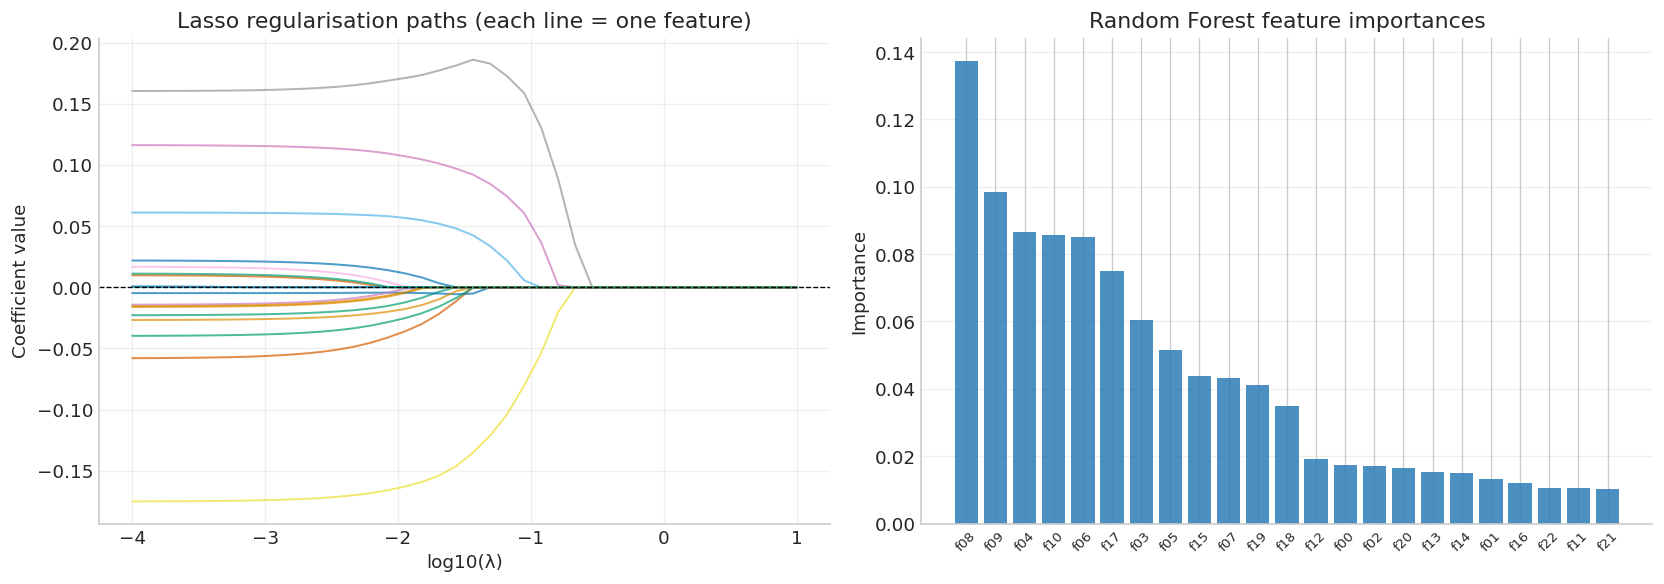

In [5]:
# --------------------------------------------------------------------------
# 3.3 Embedded: Lasso coefficient paths + Random Forest importances
# --------------------------------------------------------------------------
lambdas = np.logspace(-4, 1, 40)
coef_paths = []
for alpha in lambdas:
    lasso = Lasso(alpha=alpha, max_iter=5000, random_state=RANDOM_STATE)
    lasso.fit(X_tr, y_tr)
    coef_paths.append(lasso.coef_.copy())
coef_paths = np.array(coef_paths)   # shape (n_alphas, n_features)

rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_tr, y_tr)
rf_importance = rf.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lasso paths
for j in range(coef_paths.shape[1]):
    axes[0].plot(np.log10(lambdas), coef_paths[:, j], lw=1.2, alpha=0.7)
axes[0].axhline(0, color='black', lw=0.8, linestyle='--')
axes[0].set_xlabel("log10(λ)"); axes[0].set_ylabel("Coefficient value")
axes[0].set_title("Lasso regularisation paths (each line = one feature)")
axes[0].grid(alpha=0.3)

# Random Forest importances
order = np.argsort(rf_importance)[::-1]
axes[1].bar(np.arange(X.shape[1]), rf_importance[order],
            color=COLORS[0], alpha=0.85)
axes[1].set_xticks(np.arange(X.shape[1]))
axes[1].set_xticklabels([feature_names[i] for i in order], rotation=45, fontsize=8)
axes[1].set_title("Random Forest feature importances")
axes[1].set_ylabel("Importance"); axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

### Підсумок

**Lasso regularisation paths (ліворуч):**
- При малих $\lambda$ (ліва частина, $\log_{10}\lambda \approx -4$) усі коефіцієнти ненульові -
  регуляризація слабка, модель використовує всі ознаки.
- Зі зростанням $\lambda$ коефіцієнти послідовно «обнуляються»: спочатку найменш важливі,
  в останню чергу - найінформативніші (блакитний і наступні шляхи).
- При $\log_{10}\lambda = 0$ ($\lambda = 1$) більшість коефіцієнтів дорівнює нулю -
  модель фактично відібрала 2–3 ознаки.
- **Вертикальний зріз** при будь-якому $\lambda$ показує, які ознаки залишаються активними
  при даному рівні регуляризації.

**Random Forest feature importances (праворуч):**
- Важливості відсортовані за спаданням; чітко видно «лікоть» приблизно після 7–8 ознаки.
- Ознаки `f08`, `f09` мають суттєво вищу важливість - вони є основними предикторами.
- Хвіст (ознаки `f16`–`f21`) має майже рівномірно низьку важливість - кандидати на видалення.
- Порівняйте з Lasso: обидва методи погоджуються у виділенні провідних ознак,
  хоча ранжування може відрізнятись через різні критерії відбору.

---
<a id='extraction'></a>
## 4. Видобування рис (Feature Extraction)

На відміну від **вибору** рис, **видобування** будує **нові** ознаки - лінійні або нелінійні
комбінації оригінальних.

$$X \in \mathbb{R}^{n \times d} \;\xrightarrow{f}\; Z \in \mathbb{R}^{n \times k}, \quad k \ll d$$

Нові ознаки $Z$ більше не відповідають оригінальним вимірам.

### Таксономія методів видобування рис

```
Feature Extraction
├── Лінійні
│   ├── PCA  - максимізує дисперсію (без міток)
│   ├── SVD  - матрична факторизація (пов'язана з PCA)
│   └── LDA  - максимізує роздільність класів (з мітками)
└── Нелінійні
    ├── t-SNE / UMAP   (розглядаємо на наступному тижні)
    └── Автоенкодери   (розглядаємо пізніше в курсі)
```

---
<a id='pca'></a>
## 5. Метод головних компонент (PCA)

**PCA** (Principal Component Analysis) знаходить нову систему координат, в якій:

1. Перша вісь (перша головна компонента) спрямована вздовж напряму **максимальної дисперсії**.
2. Кожна наступна вісь - ортогональна до попередніх і охоплює максимум залишкової дисперсії.

Ключова властивість: нові координати (головні компоненти) є **некорельованими**.

### 5.1 Алгоритм PCA

Нехай $X \in \mathbb{R}^{n \times d}$ - центрована матриця даних (рядки - об'єкти).

| Крок | Дія |
|------|-----|
| 1 | Стандартизація: $x_j \leftarrow (x_j - \mu_j) / \sigma_j$ |
| 2 | Матриця коваріації: $C = \frac{1}{n-1} X^\top X \in \mathbb{R}^{d \times d}$ |
| 3 | Власний розклад: $C v_i = \lambda_i v_i$ |
| 4 | Впорядкувати за спаданням $\lambda_1 \geq \lambda_2 \geq \ldots \geq \lambda_d$ |
| 5 | Взяти перші $k$ власних векторів: $V_k \in \mathbb{R}^{d \times k}$ |
| 6 | Проекція: $Z = X V_k \in \mathbb{R}^{n \times k}$ |

### 5.2 Пояснена дисперсія

Частка дисперсії, пояснена $k$ компонентами:

$$\text{EVR}(k) = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{i=1}^{d} \lambda_i}$$

Зазвичай обирають $k$ так, щоб $\text{EVR}(k) \geq 0.90$.

In [6]:
# --------------------------------------------------------------------------
# 5. PCA step-by-step on the Iris dataset
# --------------------------------------------------------------------------
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
class_names = iris.target_names

# Step 1: standardize
scaler_iris = StandardScaler()
X_std = scaler_iris.fit_transform(X_iris)

# Step 2: covariance matrix
C = (X_std.T @ X_std) / (X_std.shape[0] - 1)

# Step 3: eigen-decomposition
eigenvalues, eigenvectors = np.linalg.eigh(C)

# Step 4: sort descending
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

# Step 5: select top-2 PCs
V2 = eigenvectors[:, :2]

# Step 6: project
Z2 = X_std @ V2

print("Covariance matrix C (4x4):")
print(np.round(C, 3))
print(f"\nEigenvalues: {np.round(eigenvalues, 4)}")

print("\nEigenvectors (columns):")
for i in range(eigenvectors.shape[1]):
    print(f"PC{i+1}: {np.round(eigenvectors[:, i], 4)}")

print("\nSelected top-2 eigenvectors (PC1 and PC2):")
print(np.round(V2, 4))

evr = eigenvalues / eigenvalues.sum()
print(f"\nExplained variance ratio: {np.round(evr, 4)}")
print(f"Cumulative EVR (first 2 PCs): {evr[:2].sum():.4f}")

Covariance matrix C (4x4):
[[ 1.007 -0.118  0.878  0.823]
 [-0.118  1.007 -0.431 -0.369]
 [ 0.878 -0.431  1.007  0.969]
 [ 0.823 -0.369  0.969  1.007]]

Eigenvalues: [2.9381 0.9202 0.1477 0.0209]

Eigenvectors (columns):
PC1: [-0.5211  0.2693 -0.5804 -0.5649]
PC2: [0.3774 0.9233 0.0245 0.0669]
PC3: [ 0.7196 -0.2444 -0.1421 -0.6343]
PC4: [ 0.2613 -0.1235 -0.8014  0.5236]

Selected top-2 eigenvectors (PC1 and PC2):
[[-0.5211  0.3774]
 [ 0.2693  0.9233]
 [-0.5804  0.0245]
 [-0.5649  0.0669]]

Explained variance ratio: [0.7296 0.2285 0.0367 0.0052]
Cumulative EVR (first 2 PCs): 0.9581


### Підсумок

- Матриця коваріації $C$ виявляє сильні кореляції між ознаками пелюсток (`petal length`, `petal width`) - ці ознаки несуть схожу інформацію, що й зумовлює ефективність PCA.
- Перші дві компоненти (PC1 + PC2) пояснюють **~96% загальної дисперсії** - це наочний приклад зниження розмірності з 4 до 2 зі збереженням майже всієї інформації.
- Власні вектори показують, що `petal length` і `petal width` найбільше визначають PC1, тоді як `sepal width` переважно описує PC2.

### Візуалізація результатів PCA: Scree Plot, 2D-проекція та навантаження

Тепер побудуємо три графіки для наочного представлення отриманих результатів:  
1. **Scree Plot** - власні значення та накопичена пояснена дисперсія (EVR) для вибору $k$.  
2. **2D-проекція** - 150 зразків Iris у просторі перших двох головних компонент.  
3. **Навантаження (loadings)** - напрямки оригінальних ознак у новому просторі компонент.

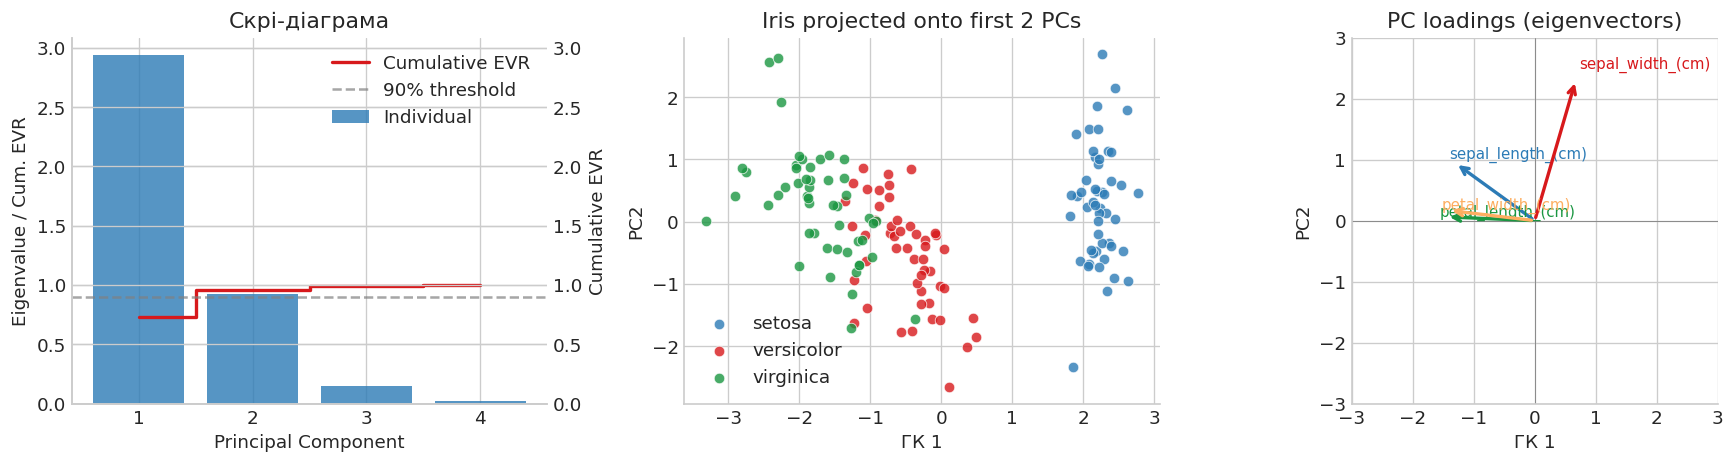

In [7]:
# --------------------------------------------------------------------------
# Scree plot + 2D projection
# --------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Scree plot ────────────────────────────────────────────────────────────────
axes[0].bar(range(1, len(eigenvalues)+1), eigenvalues,
            color=COLORS[0], alpha=0.8, label="Individual")
axes[0].step(range(1, len(eigenvalues)+1), np.cumsum(evr), where='mid',
             color=COLORS[1], lw=2, label="Cumulative EVR")
axes[0].axhline(0.9, linestyle='--', color='gray', alpha=0.7, label="90% threshold")
axes[0].set_xlabel("Principal Component"); axes[0].set_ylabel("Eigenvalue / Cum. EVR")
axes[0].set_title("Скрі-діаграма"); axes[0].legend()
ax2 = axes[0].twinx()
ax2.set_ylabel("Cumulative EVR"); ax2.set_ylim(axes[0].get_ylim())

# ── 2D PCA projection ─────────────────────────────────────────────────────────
for cls, color, name in zip([0,1,2], COLORS[:3], class_names):
    mask = y_iris == cls
    axes[1].scatter(Z2[mask, 0], Z2[mask, 1], color=color, label=name,
                    s=40, alpha=0.8, edgecolors='white', linewidths=0.5)
axes[1].set_xlabel("ГК 1"); axes[1].set_ylabel("PC2")
axes[1].set_title("Iris projected onto first 2 PCs"); axes[1].legend()

# ── Loadings (eigenvectors as arrows) ────────────────────────────────────────
feature_labels = [n.replace(" ", "_") for n in iris.feature_names]
for i, (feat, vec) in enumerate(zip(feature_labels, V2)):
    axes[2].annotate("", xy=(vec[0]*2.5, vec[1]*2.5), xytext=(0,0),
                     arrowprops=dict(arrowstyle='->', color=COLORS[i], lw=2))
    axes[2].text(vec[0]*2.7, vec[1]*2.7, feat.split()[0], fontsize=9,
                 color=COLORS[i])
axes[2].set_xlim(-3, 3); axes[2].set_ylim(-3, 3)
axes[2].axhline(0, color='gray', lw=0.5); axes[2].axvline(0, color='gray', lw=0.5)
axes[2].set_title("PC loadings (eigenvectors)"); axes[2].set_xlabel("ГК 1"); axes[2].set_ylabel("PC2")
axes[2].set_aspect('equal')

plt.tight_layout(); plt.show()

### Підсумок

**Scree Plot (ліворуч):**
- PC1 пояснює ~73% дисперсії (найбільший власний вектор) - більшість інформації
  зосереджена в одному напрямку.
- PC1 + PC2 разом пояснюють ~96% дисперсії, перетинаючи поріг 90% вже на другій компоненті.
- PC3 і PC4 несуть мінімальну додаткову інформацію - їх можна відкинути без суттєвих втрат.
- «Лікоть» (elbow) чітко видно між PC2 і PC3, що підтверджує вибір $k=2$.

**Проекція на перші 2 головні компоненти (по центру):**
- Клас *setosa* (синій) повністю відокремлений від двох інших уздовж PC1 -
  лінійно роздільний навіть в 1D.
- Класи *versicolor* (червоний) та *virginica* (зелений) частково перекриваються,
  що відповідає відомій складності їх розрізнення.
- PC2 вносить додаткову роздільність між *versicolor* та *virginica*, але не повну.

**PC Loadings - власні вектори (праворуч):**
- Стрілки показують напрямки оригінальних ознак у просторі головних компонент.
- `petal length` та `petal width` (жовтий і зелений) майже паралельні та спрямовані
  вздовж PC1 - вони є основними «рушіями» першої компоненти.
- `sepal length` (червоний) також суттєво корелює з PC1, але має помітну складову вздовж PC2.
- `sepal width` (синій) спрямований переважно вздовж PC2 і майже перпендикулярний до решти -
  він несе унікальну інформацію, яку інші ознаки не охоплюють.
- Довжина стрілки відповідає «силі» внеску ознаки в цю площину проекції.

### 5.3 Вибір кількості компонент $k$

Практичне правило: будуємо графік поясненої дисперсії та шукаємо **«лікоть» (elbow)**
або порогове значення (наприклад, 90%).

Також корисно порівнювати якість реконструкції:

$$\hat{X} = Z V_k^\top, \qquad \text{MSE} = \frac{1}{n \cdot d}\|X - \hat{X}\|_F^2$$

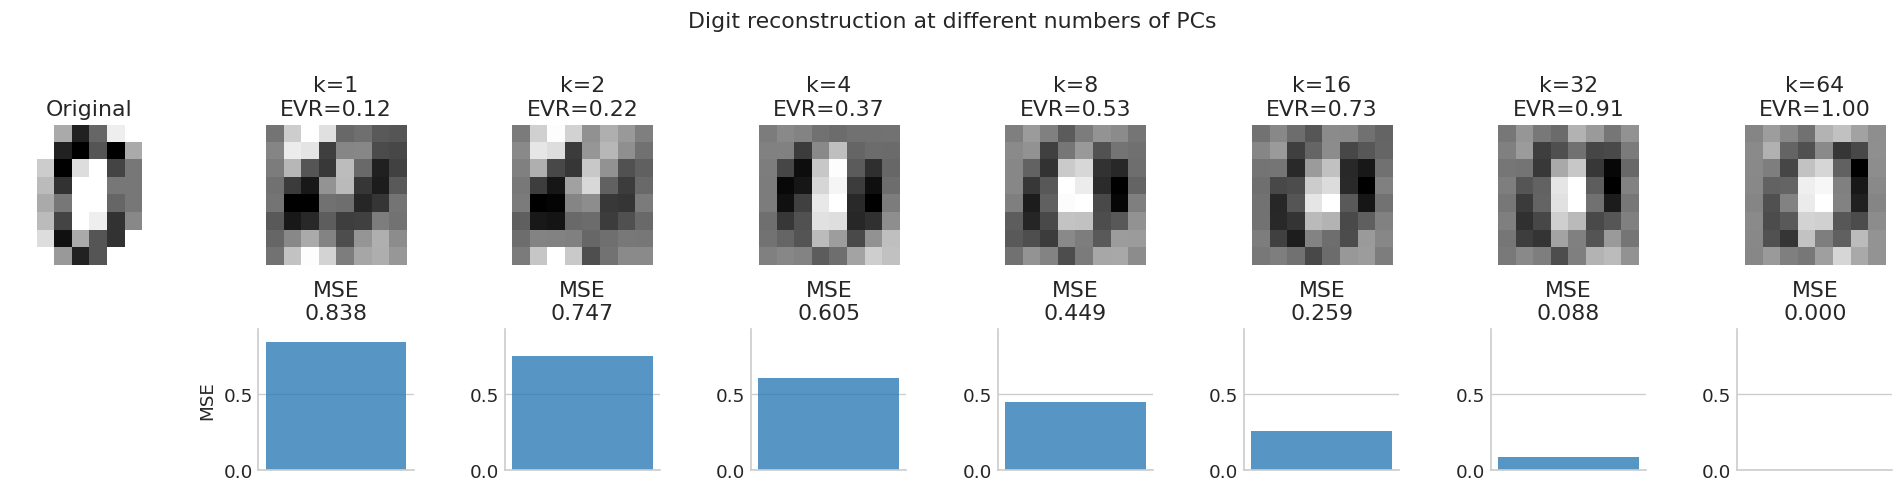

In [8]:
# --------------------------------------------------------------------------
# Reconstruction quality vs number of PCs (on digit images)
# --------------------------------------------------------------------------
digits = load_digits()
X_dig = StandardScaler().fit_transform(digits.data.astype(float))

mse_vals, evr_cumsum = [], []
all_evals, all_evecs = np.linalg.eigh(X_dig.T @ X_dig / (X_dig.shape[0]-1))
order_d = np.argsort(all_evals)[::-1]
all_evals = all_evals[order_d]
all_evecs = all_evecs[:, order_d]
evr_d = all_evals / all_evals.sum()

k_range = [1, 2, 4, 8, 16, 32, 64]
sample_idx = 0  # which digit to reconstruct

fig, axes = plt.subplots(2, len(k_range)+1, figsize=(16, 4))

# Original
axes[0, 0].imshow(digits.images[sample_idx], cmap='gray_r'); axes[0, 0].axis('off')
axes[0, 0].set_title("Original")
axes[1, 0].axis('off')

for col, k in enumerate(k_range, start=1):
    Vk = all_evecs[:, :k]
    Z_k = X_dig @ Vk
    X_rec = Z_k @ Vk.T         # reconstruct in original space
    mse = np.mean((X_dig - X_rec) ** 2)
    mse_vals.append(mse)
    evr_cumsum.append(evr_d[:k].sum())

    img_rec = X_rec[sample_idx].reshape(8, 8)
    axes[0, col].imshow(img_rec, cmap='gray_r'); axes[0, col].axis('off')
    axes[0, col].set_title(f"k={k}\nEVR={evr_d[:k].sum():.2f}")

    axes[1, col].bar(0, mse, color=COLORS[0], alpha=0.8)
    axes[1, col].set_ylim(0, mse_vals[0]*1.1)
    axes[1, col].set_xticks([]); axes[1, col].set_ylabel("MSE" if col==1 else "")
    axes[1, col].set_title(f"MSE\n{mse:.3f}")

plt.suptitle("Digit reconstruction at different numbers of PCs", y=1.02)
plt.tight_layout(); plt.show()

### Підсумок

- При **$k = 1$–$2$** цифра майже нерозпізнавана: зберігається лише найзагальніший контур, MSE висока.
- При **$k = 4$–$16$** якість реконструкції стрімко зростає - цифра читається чітко, а MSE знижується в кілька разів.
- При **$k = 32$** зображення практично непомітно відрізняється від оригіналу, при цьому розмірність суттєво скорочена ($d = 64$).
- Цей приклад наочно демонструє: більшість корисної інформації в даних зосереджена у перших кількох головних компонентах, що «стискають» зображення без суттєвих втрат якості.

---
<a id='svd'></a>
## 6. Сингулярний розклад (SVD)

**SVD** (Singular Value Decomposition) - фундаментальна матрична факторизація:

$$X = U \Sigma V^\top$$

де:
* $U \in \mathbb{R}^{n \times n}$ - ліва унітарна матриця; стовпці $\mathbf{u}_i$ називаються **лівими сингулярними векторами**; $U^\top U = I$
* $\Sigma \in \mathbb{R}^{n \times d}$ - діагональна матриця **сингулярних значень** $\sigma_1 \geq \sigma_2 \geq \ldots \geq \sigma_r \geq 0$, де $r = \text{rank}(X)$
* $V \in \mathbb{R}^{d \times d}$ - права унітарна матриця; стовпці $\mathbf{v}_i$ називаються **правими сингулярними векторами**; $V^\top V = I$

### 6.1 Алгоритм SVD

| Крок | Дія |
|------|-----|
| 1 | Обчислити $X^\top X \in \mathbb{R}^{d \times d}$ |
| 2 | Знайти власні значення та вектори: $X^\top X \mathbf{v}_i = \sigma_i^2 \mathbf{v}_i$ |
| 3 | Сингулярні значення: $\sigma_i = \sqrt{\lambda_i(X^\top X)}$, впорядковані за спаданням |
| 4 | Праві сингулярні вектори: стовпці $V$ = власні вектори $X^\top X$ |
| 5 | Ліві сингулярні вектори: $\mathbf{u}_i = \frac{1}{\sigma_i} X \mathbf{v}_i$ |
| 6 | Зібрати $U$, $\Sigma$, $V^\top$ |

На практиці повний SVD обчислюється через алгоритм Голуба-Рейнша (bidiagonalization + QR), але концептуально кроки вище точно відповідають тому, що відбувається.

### 6.2 Зв'язок SVD з PCA

Якщо $X$ центровано ($\mathbf{1}^\top X = 0$), то коваріаційна матриця розкладається як:

$$C = \frac{1}{n-1} X^\top X = \frac{1}{n-1} V \Sigma^2 V^\top$$

Порівняємо з власним розкладом $C = V \Lambda V^\top$:

$$\lambda_i = \frac{\sigma_i^2}{n-1}$$

Тобто:
* Стовпці $V$ - одночасно праві сингулярні вектори **і** власні вектори коваріаційної матриці (= напрямки головних компонент PCA)
* Проекція $Z = XV = U\Sigma$ - координати точок у новому просторі

**Висновок:** PCA на центрованих даних - це рівно truncated SVD матриці $X$.

### 6.3 Низькорангове наближення (Truncated SVD)

Повний SVD можна записати як суму матриць рангу 1:

$$X = \sum_{i=1}^{r} \sigma_i \mathbf{u}_i \mathbf{v}_i^\top$$

**Truncated SVD** зберігає лише перші $k$ доданків:

$$\hat{X}_k = \sum_{i=1}^{k} \sigma_i \mathbf{u}_i \mathbf{v}_i^\top = U_k \Sigma_k V_k^\top$$

Кожен доданок $\sigma_i \mathbf{u}_i \mathbf{v}_i^\top$ - це матриця рангу 1, що описує один «патерн» у даних.
Великі $\sigma_i$ відповідають сильним, систематичним патернам; малі $\sigma_i$ - шуму.
Відкидаючи доданки з малими $\sigma_i$, ми **зберігаємо структуру і прибираємо шум**.

За теоремою Eckart-Young-Mirsky, $\hat{X}_k$ є **найкращим** наближенням ранг-$k$ у нормі Фробеніуса:

$$\hat{X}_k = \arg\min_{\text{rank}(B) = k} \|X - B\|_F^2, \qquad \|X - \hat{X}_k\|_F^2 = \sum_{i=k+1}^{r} \sigma_i^2$$

Похибка реконструкції точно дорівнює сумі квадратів відкинутих сингулярних значень.

Reconstruction error (Frobenius): 0.0

Singular values - manual vs numpy:
  σ1: manual=20.923066  numpy=20.923066
  σ2: manual=11.709166  numpy=11.709166
  σ3: manual=4.691858  numpy=4.691858
  σ4: manual=1.762732  numpy=1.762732

Eigenvalues: from SVD  vs  direct eigen-decomposition of C:
  PC1: σ²/(n-1) = 2.938085   λ = 2.938085
  PC2: σ²/(n-1) = 0.920165   λ = 0.920165
  PC3: σ²/(n-1) = 0.147742   λ = 0.147742
  PC4: σ²/(n-1) = 0.020854   λ = 0.020854


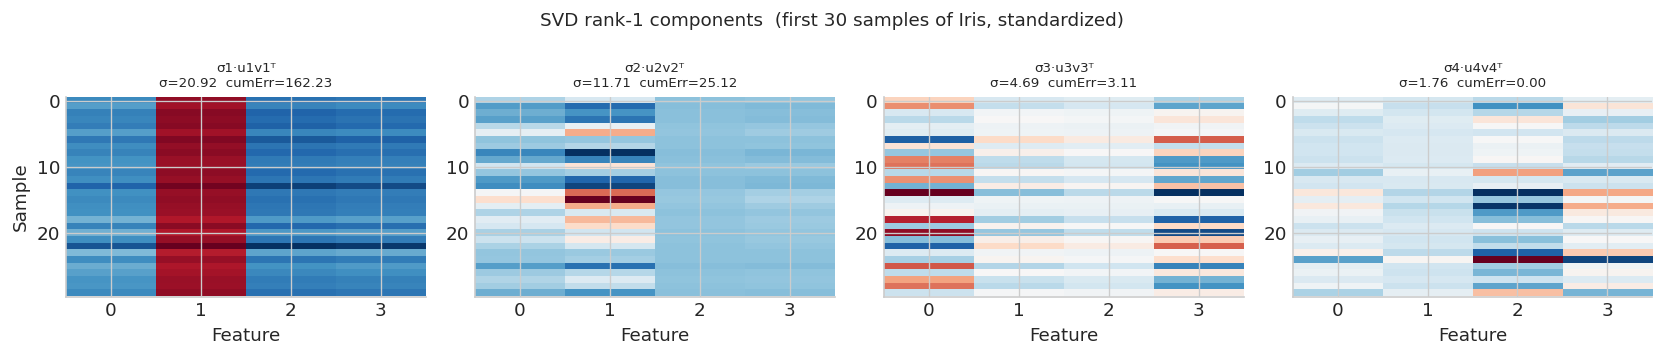

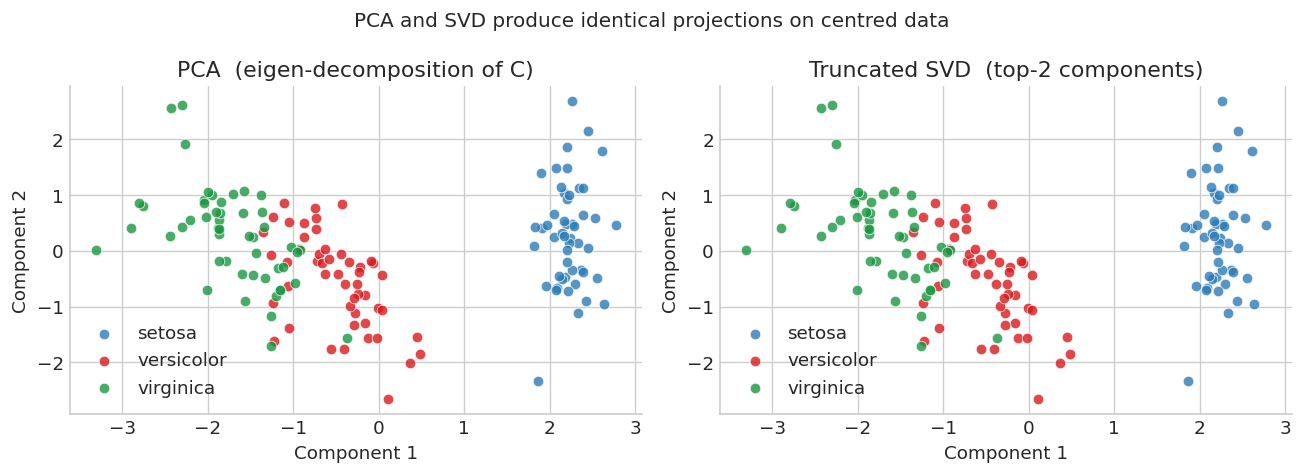


Max absolute difference |PCA scores| vs |SVD scores|: 0.0 ← effectively zero


In [9]:
# --------------------------------------------------------------------------
# 6. SVD step-by-step on Iris (mirror of the PCA walkthrough)
# --------------------------------------------------------------------------

# Step 1-2: compute X^T X and its eigenvectors
XtX = X_std.T @ X_std                          # (4, 4)
eig_vals_xtx, eig_vecs_xtx = np.linalg.eigh(XtX)

# Step 3: singular values = sqrt(eigenvalues of X^T X), sort descending
order_svd = np.argsort(eig_vals_xtx)[::-1]
singular_values = np.sqrt(np.maximum(eig_vals_xtx[order_svd], 0))
V_manual = eig_vecs_xtx[:, order_svd]          # right singular vectors (4, 4)

# Step 5: left singular vectors u_i = (1/sigma_i) * X v_i
U_manual = X_std @ V_manual / singular_values   # (150, 4)

# Reconstruction check: X ≈ U Σ V^T
Sigma_manual = np.diag(singular_values)
X_reconstructed = U_manual @ Sigma_manual @ V_manual.T
print("Reconstruction error (Frobenius):",
      np.round(np.linalg.norm(X_std - X_reconstructed), 8))

# Verify singular values match numpy's svd
_, s_np, _ = np.linalg.svd(X_std, full_matrices=False)
print("\nSingular values - manual vs numpy:")
for i, (sm, sn) in enumerate(zip(singular_values, s_np)):
    print(f"  σ{i+1}: manual={sm:.6f}  numpy={sn:.6f}")

# Relationship to PCA eigenvalues
lambda_from_sv = singular_values**2 / (X_std.shape[0] - 1)
print("\nEigenvalues: from SVD  vs  direct eigen-decomposition of C:")
for i, (lsvd, leig) in enumerate(zip(lambda_from_sv, eigenvalues)):
    print(f"  PC{i+1}: σ²/(n-1) = {lsvd:.6f}   λ = {leig:.6f}")

# --------------------------------------------------------------------------
# Rank-1 components: show each addend sigma_i * u_i * v_i^T
# --------------------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

cumulative = np.zeros_like(X_std)
for i in range(4):
    rank1 = singular_values[i] * np.outer(U_manual[:, i], V_manual[:, i])
    cumulative += rank1
    err = np.linalg.norm(X_std - cumulative, 'fro')**2

    axes[i].imshow(rank1[:30], aspect='auto', cmap='RdBu_r')   # show first 30 rows
    axes[i].set_title(f"σ{i+1}·u{i+1}v{i+1}ᵀ\n"
                      f"σ={singular_values[i]:.2f}  "
                      f"cumErr={err:.2f}", fontsize=8)
    axes[i].set_xlabel("Feature"); axes[i].set_ylabel("Sample" if i == 0 else "")

plt.suptitle("SVD rank-1 components  (first 30 samples of Iris, standardized)",
             fontsize=11)
plt.tight_layout(); plt.show()

# --------------------------------------------------------------------------
# Truncated SVD projection (top-2) vs PCA projection - they must match
# --------------------------------------------------------------------------
Z_svd_2 = U_manual[:, :2] * singular_values[:2]   # scores: U_k Σ_k

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, Z, title in [(axes[0], Z2,      "PCA  (eigen-decomposition of C)"),
                     (axes[1], Z_svd_2, "Truncated SVD  (top-2 components)")]:
    for cls, color, name in zip([0, 1, 2], COLORS[:3], class_names):
        mask = y_iris == cls
        ax.scatter(Z[mask, 0], Z[mask, 1], color=color, label=name,
                   s=40, alpha=0.8, edgecolors='white', linewidths=0.5)
    ax.set_xlabel("Component 1"); ax.set_ylabel("Component 2")
    ax.set_title(title); ax.legend()

plt.suptitle("PCA and SVD produce identical projections on centred data", fontsize=12)
plt.tight_layout(); plt.show()

print("\nMax absolute difference |PCA scores| vs |SVD scores|:",
      np.abs(np.abs(Z2) - np.abs(Z_svd_2)).max().round(8),
      "← effectively zero")

### Підсумок
- Помилка реконструкції $\|X - U\Sigma V^\top\|_F \approx 0$ підтверджує коректність ручної реалізації SVD.
- Сингулярні значення, обчислені через власний розклад $X^\top X$, збігаються з результатами `np.linalg.svd` з точністю до машинної похибки.
- Проекції PCA і truncated SVD є **ідентичними** (можлива різниця лише у знаку): $\lambda_i = \sigma_i^2 / (n-1)$.
- Ранг-1 компоненти $\sigma_i \mathbf{u}_i \mathbf{v}_i^\top$ демонструють ієрархію «патернів»: перший доданок несе найбільший внесок, кожен наступний - дедалі менший.

### Низькорангове наближення та денойзинг

Побудуємо синтетичну матрицю

$$
A = S + E,
$$

де $S$ - структурований низькоранговий сигнал, а $E$ - гаусівський шум. У цьому прикладі

$$
S = uv^\top,
$$

тобто чистий сигнал має ранг $1$.

Далі обчислимо повний сингулярний розклад

$$
A = U \Sigma V^\top
$$

і побудуємо truncated SVD-апроксимації

$$
A_k = U_k \Sigma_k V_k^\top
$$

для кількох значень $k$.

Мета цього прикладу - проілюструвати дві близькі, але не тотожні ідеї:

1. **Теорема Екарта–Янга:** матриця $A_k$ є найкращим наближенням рангу $k$ до матриці $A$ у сенсі норми Фробеніуса
2. **Інтерпретація як денойзингу:** якщо корисна структура зосереджена в перших кількох сингулярних компонентах, то усічення розкладу може зберегти сигнал і водночас відкинути частину шуму.

Тому в цьому експерименті ми подивимося:

- як змінюється вигляд матриці $A_k$ зі зростанням $k$;
- як спадає помилка наближення $\|A-A_k\|_F^2$;
- і що графік сингулярних значень говорить нам про наявність низьковимірної структури.

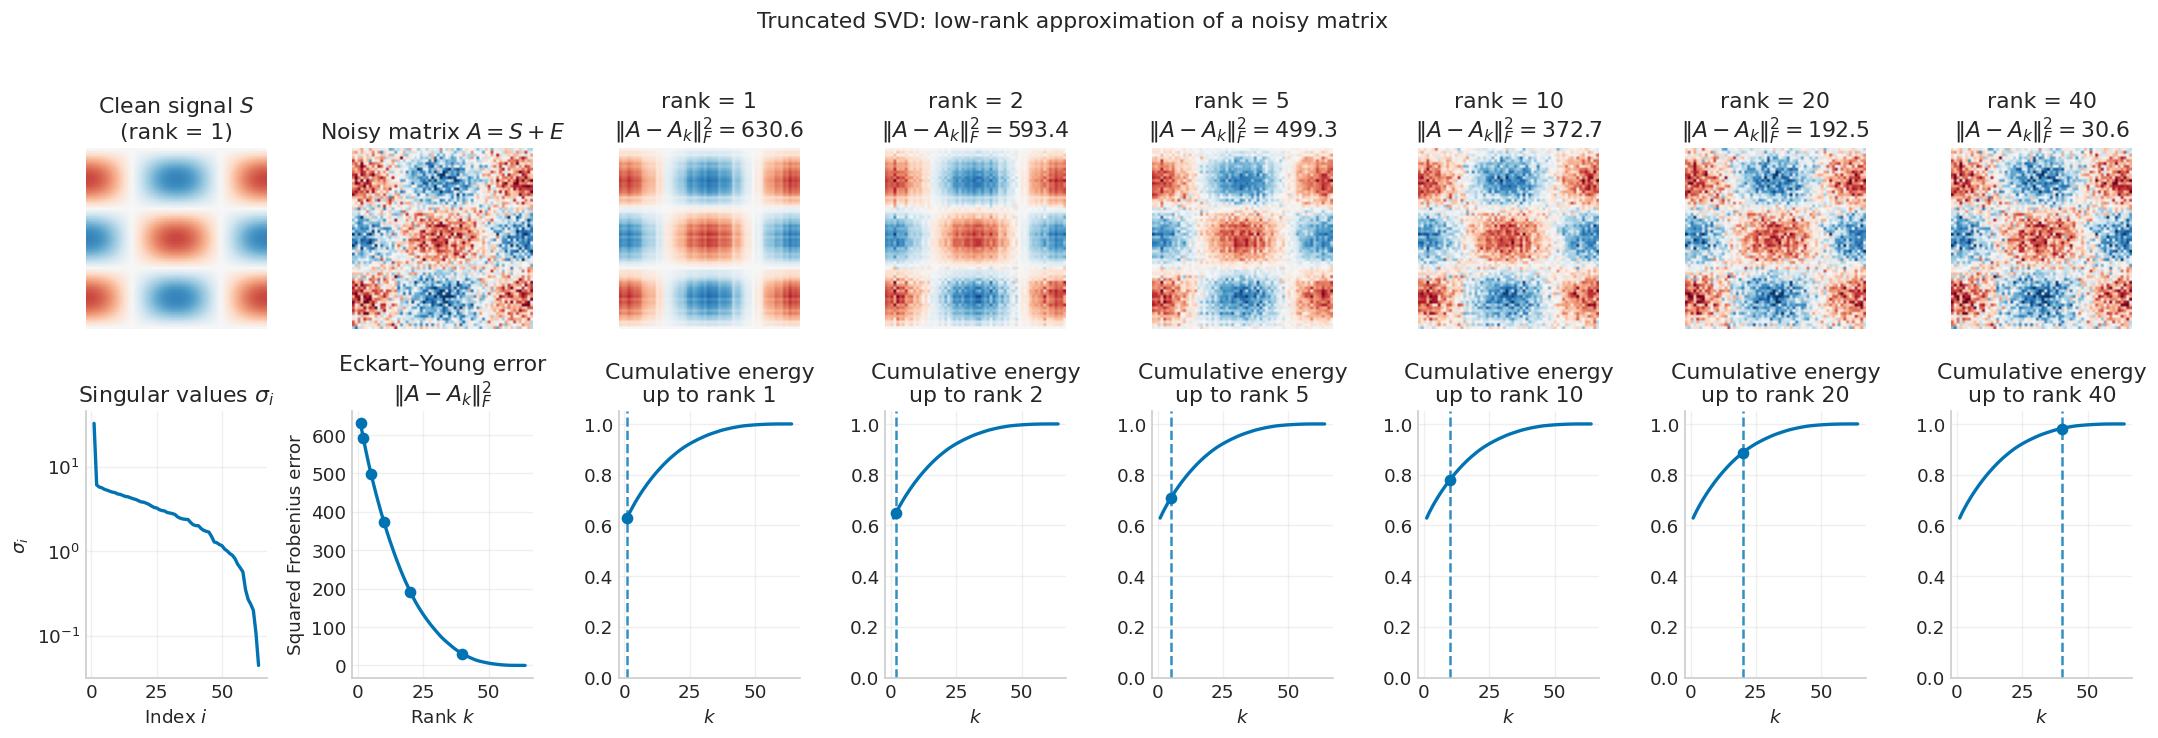

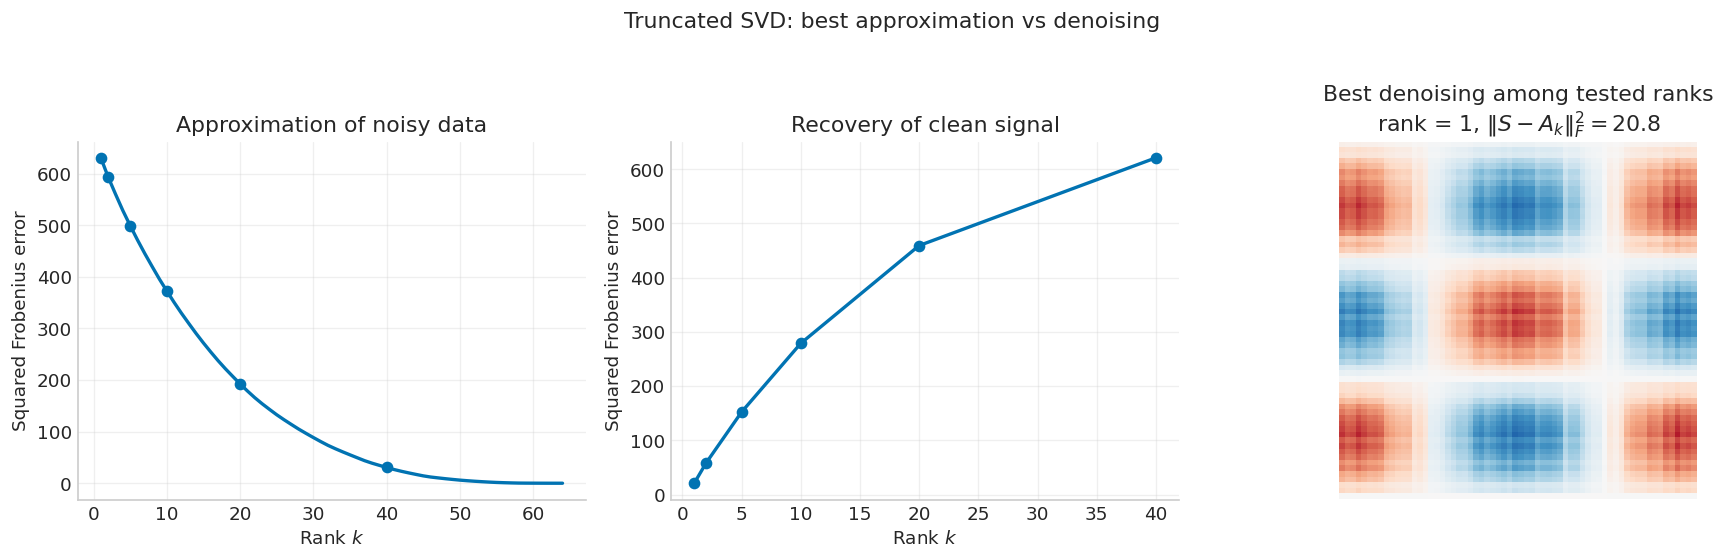

In [10]:
# --------------------------------------------------------------------------
# 6. Truncated SVD: low-rank approximation and denoising
# --------------------------------------------------------------------------
np.random.seed(42)

# --- 1. Generate clean low-rank signal and noisy observation
n_rows = 64

u_true = np.sin(np.linspace(0, 3 * np.pi, n_rows))
v_true = np.cos(np.linspace(0, 2 * np.pi, n_rows))

S = np.outer(u_true, v_true)                     # clean rank-1 signal
E = np.random.randn(n_rows, n_rows) * 0.4        # Gaussian noise
A = S + E                                        # observed noisy matrix

# --- 2. Full SVD of the noisy matrix
U, s, Vt = np.linalg.svd(A, full_matrices=False)

# --- 3. Ranks to inspect
ranks = [1, 2, 5, 10, 20, 40]

# Containers
A_approx = {}
err_to_A = []
err_to_S = []

for k in ranks:
    Ak = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    A_approx[k] = Ak

    # Best rank-k approximation error to the noisy matrix A
    err_A = np.linalg.norm(A - Ak, ord='fro')**2
    err_to_A.append(err_A)

    # Error to the clean signal S (for denoising analysis)
    err_S = np.linalg.norm(S - Ak, ord='fro')**2
    err_to_S.append(err_S)

# --- 4. Error curve for all k (not only selected ranks)
all_k = np.arange(1, len(s) + 1)
all_err_to_A = np.array([np.sum(s[k:]**2) for k in range(1, len(s) + 1)])

# Optional: cumulative explained energy
cum_energy = np.cumsum(s**2) / np.sum(s**2)

# --------------------------------------------------------------------------
# Figure 1: matrices + singular values + Eckart-Young error
# --------------------------------------------------------------------------
fig, axes = plt.subplots(2, len(ranks) + 2, figsize=(18, 6))

# First row: clean signal and noisy observation
axes[0, 0].imshow(S, cmap='RdBu_r', vmin=-1.5, vmax=1.5)
axes[0, 0].set_title("Clean signal $S$\n(rank = 1)")
axes[0, 0].axis('off')

axes[0, 1].imshow(A, cmap='RdBu_r', vmin=-1.5, vmax=1.5)
axes[0, 1].set_title("Noisy matrix $A = S + E$")
axes[0, 1].axis('off')

# Rank-k approximations
for col, k in enumerate(ranks, start=2):
    axes[0, col].imshow(A_approx[k], cmap='RdBu_r', vmin=-1.5, vmax=1.5)
    axes[0, col].set_title(f"rank = {k}\n$\\|A-A_k\\|_F^2={err_to_A[ranks.index(k)]:.1f}$")
    axes[0, col].axis('off')

# Second row, left: singular values
axes[1, 0].semilogy(np.arange(1, len(s) + 1), s, lw=2)
axes[1, 0].set_title("Singular values $\\sigma_i$")
axes[1, 0].set_xlabel("Index $i$")
axes[1, 0].set_ylabel("$\\sigma_i$")
axes[1, 0].grid(alpha=0.3)

# Second row, second plot: error to A as function of k
axes[1, 1].plot(all_k, all_err_to_A, lw=2)
axes[1, 1].scatter(ranks, err_to_A, zorder=3)
axes[1, 1].set_title("Eckart–Young error\n$\\|A-A_k\\|_F^2$")
axes[1, 1].set_xlabel("Rank $k$")
axes[1, 1].set_ylabel("Squared Frobenius error")
axes[1, 1].grid(alpha=0.3)

# Remaining bottom plots: cumulative energy up to each selected k
for col, k in enumerate(ranks, start=2):
    axes[1, col].plot(np.arange(1, len(s) + 1), cum_energy, lw=2)
    axes[1, col].axvline(k, linestyle='--', alpha=0.8)
    axes[1, col].scatter([k], [cum_energy[k - 1]], zorder=3)
    axes[1, col].set_title(f"Cumulative energy\nup to rank {k}")
    axes[1, col].set_xlabel("$k$")
    axes[1, col].set_ylim(0, 1.05)
    axes[1, col].grid(alpha=0.3)

plt.suptitle("Truncated SVD: low-rank approximation of a noisy matrix", y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------
# Figure 2: denoising interpretation
# --------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Error to noisy matrix
axes[0].plot(all_k, all_err_to_A, lw=2, label=r"$\|A-A_k\|_F^2$")
axes[0].scatter(ranks, err_to_A, zorder=3)
axes[0].set_title("Approximation of noisy data")
axes[0].set_xlabel("Rank $k$")
axes[0].set_ylabel("Squared Frobenius error")
axes[0].grid(alpha=0.3)

# Error to clean signal
axes[1].plot(ranks, err_to_S, marker='o', lw=2, label=r"$\|S-A_k\|_F^2$")
axes[1].set_title("Recovery of clean signal")
axes[1].set_xlabel("Rank $k$")
axes[1].set_ylabel("Squared Frobenius error")
axes[1].grid(alpha=0.3)

# Best denoising candidate among inspected ranks
best_idx = int(np.argmin(err_to_S))
best_k = ranks[best_idx]

axes[2].imshow(A_approx[best_k], cmap='RdBu_r', vmin=-1.5, vmax=1.5)
axes[2].set_title(
    f"Best denoising among tested ranks\n"
    f"rank = {best_k}, "
    f"$\\|S-A_k\\|_F^2={err_to_S[best_idx]:.1f}$"
)
axes[2].axis('off')

plt.suptitle("Truncated SVD: best approximation vs denoising", y=1.03)
plt.tight_layout()
plt.show()

### Підсумок

Чиста матриця $S$ містить гладкий тригонометричний патерн рангу $1$, а матриця $A$ є його зашумленою версією. Реконструкції $A_k$ показують, як truncated SVD поступово додає дедалі більше деталей зі зростанням $k$.

Основні спостереження такі:

- **При дуже малих рангах** ($k=1,2$) вже добре видно головну глобальну структуру. Це очікувано, оскільки істинний сигнал у нашому прикладі має ранг $1$.
- **Зі збільшенням $k$** апроксимація стає дедалі ближчою до шумної матриці $A$, тому помилка

$$
\|A-A_k\|_F^2
$$

монотонно зменшується.

- **Графік сингулярних значень** показує, що перші кілька компонент несуть основну частину енергії матриці, тоді як решта утворює довгий хвіст менших значень.
- **Графіки накопиченої енергії** показують, яку частку загальної енергії зберігає наближення при використанні лише перших $k$ сингулярних значень.

Ключова інтерпретація тут така:

- З погляду **наближення матриці** більші значення $k$ завжди кращі, оскільки truncated SVD дає оптимальне rank-$k$ наближення.
- З погляду **денойзингу** часто корисно брати мале $k$: достатньо велике, щоб зберегти основну структуру, але не настільки велике, щоб почати відтворювати шум.

Отже, truncated SVD є корисним одночасно як інструмент **зменшення розмірності** і як проста модель **виділення сигналу із зашумлених даних**.

---
<a id='lda'></a>
## 7. Лінійний дискримінантний аналіз (LDA)

На відміну від PCA, **LDA** - **контрольований** метод: він використовує мітки класів $y$.

### 7.1 Мета LDA

Знайти проекцію, що **максимізує** розбиття між класами і **мінімізує** розкид всередині класів.

Критерій Фішера (для $C$ класів):

$$J(W) = \frac{W^\top S_B W}{W^\top S_W W}$$

де:
* $S_W = \sum_{c=1}^{C} \sum_{i : y_i = c} (x_i - \mu_c)(x_i - \mu_c)^\top$ - матриця розсіювання **всередині** класів
* $S_B = \sum_{c=1}^{C} n_c (\mu_c - \mu)(\mu_c - \mu)^\top$ - матриця розсіювання **між** класами

Оптимальні напрямки $W^*$ - власні вектори матриці $S_W^{-1} S_B$.

### 7.2 Обмеження LDA

* Максимум $C-1$ дискримінантних напрямків (для $C$ класів)
* Передбачає нормальність та рівність коваріаційних матриць класів
* Тільки для задач із мітками - **supervised**

### 7.3 PCA vs LDA

| | PCA | LDA |
|---|---|---|
| Тип | Unsupervised | Supervised |
| Критерій | Максимальна дисперсія | Максимальна розбиття між класами |
| Мітки | Не потрібні | Обов'язкові |
| Макс. компонент | $\min(n,d)-1$ | $C-1$ |
| Нові ознаки | Некорельовані | Оптимальні для класифікації |

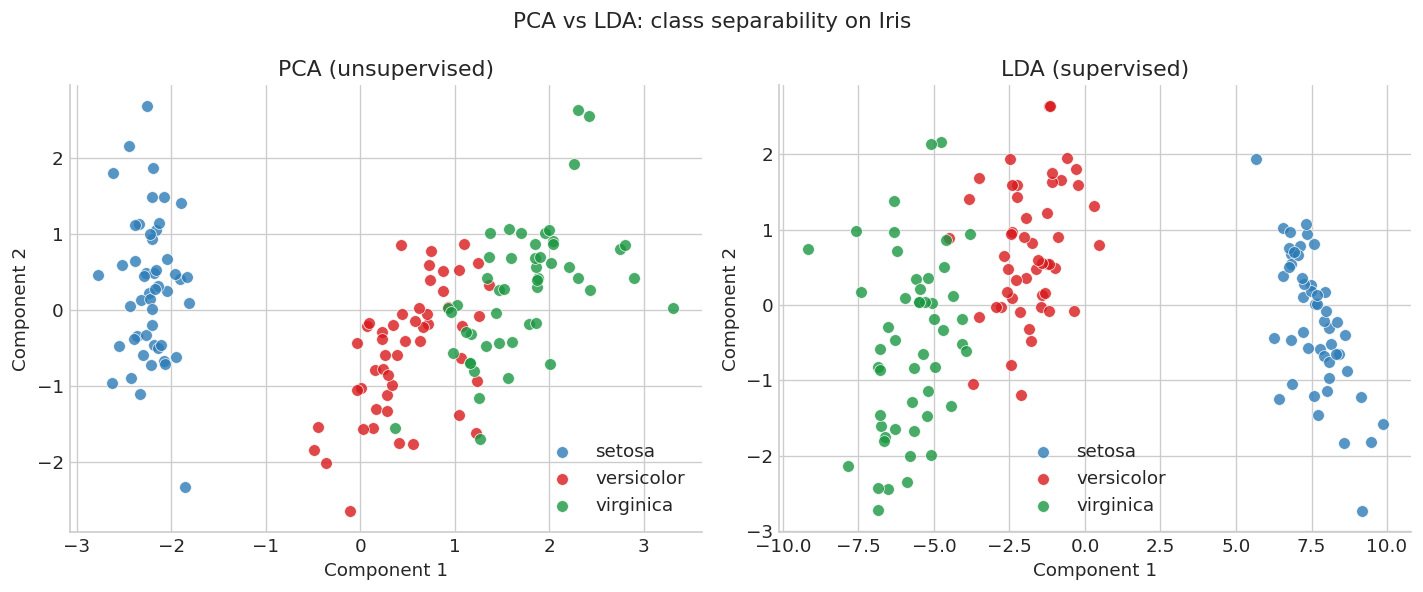

In [11]:
# --------------------------------------------------------------------------
# 7. PCA vs LDA comparison on Iris
# --------------------------------------------------------------------------
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
Z_pca = pca2.fit_transform(X_std)

lda2 = LinearDiscriminantAnalysis(n_components=2)
Z_lda = lda2.fit_transform(X_std, y_iris)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, Z, title in [(axes[0], Z_pca, "PCA (unsupervised)"),
                     (axes[1], Z_lda, "LDA (supervised)")]:
    for cls, color, name in zip([0,1,2], COLORS[:3], class_names):
        mask = y_iris == cls
        ax.scatter(Z[mask, 0], Z[mask, 1], color=color, label=name,
                   s=50, alpha=0.8, edgecolors='white', linewidths=0.5)
    ax.set_xlabel("Component 1"); ax.set_ylabel("Component 2")
    ax.set_title(title); ax.legend()

plt.suptitle("PCA vs LDA: class separability on Iris", fontsize=13)
plt.tight_layout(); plt.show()

### Підсумок

- **PCA** (ліворуч) відокремлює *setosa* вздовж PC1, утім *versicolor* і *virginica* суттєво перекриваються у 2D-просторі.
- **LDA** (праворуч) забезпечує значно кращу роздільність: усі три класи утворюють компактні кластери з мінімальним перекриттям.
- Різниця зумовлена критерієм оптимізації: PCA максимізує **загальну дисперсію** (без міток), LDA - **відношення міжкласової дисперсії до внутрішньокласової** (з мітками класів).

### Покрокова реалізація LDA вручну (без sklearn)

Щоб глибше зрозуміти математику LDA, реалізуємо алгоритм з нуля:
1. Обчислимо матрицю розсіювання **всередині класів** $S_W$ - сума відхилень точок від центроїдів їхніх класів.
2. Обчислимо матрицю розсіювання **між класами** $S_B$ - зважена сума квадратів відстаней між центроїдами класів та глобальним середнім.
3. Розв'яжемо узагальнену задачу на власні значення $S_W^{-1} S_B \mathbf{w} = \lambda \mathbf{w}$ та відберемо перші $C-1$ напрямків.

In [12]:
# --------------------------------------------------------------------------
# Manual LDA step-by-step (no sklearn) to illustrate the math
# --------------------------------------------------------------------------
classes = np.unique(y_iris)
n_features = X_std.shape[1]
mu_global = X_std.mean(axis=0)

# Within-class scatter matrix S_W
S_W = np.zeros((n_features, n_features))
for c in classes:
    X_c = X_std[y_iris == c]
    mu_c = X_c.mean(axis=0)
    diff_c = X_c - mu_c
    S_W += diff_c.T @ diff_c

# Between-class scatter matrix S_B
S_B = np.zeros((n_features, n_features))
for c in classes:
    X_c = X_std[y_iris == c]
    mu_c = X_c.mean(axis=0)
    n_c = X_c.shape[0]
    diff_mu = (mu_c - mu_global).reshape(-1, 1)
    S_B += n_c * (diff_mu @ diff_mu.T)

# Solve generalised eigenvalue problem: S_W^{-1} S_B w = lambda w
eig_vals, eig_vecs = np.linalg.eig(np.linalg.pinv(S_W) @ S_B)
eig_vals = eig_vals.real; eig_vecs = eig_vecs.real
order_lda = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[order_lda]; eig_vecs = eig_vecs[:, order_lda]

W2_lda = eig_vecs[:, :2]
Z_lda_manual = X_std @ W2_lda

print("LDA eigenvalues (Fisher criterion):", np.round(eig_vals, 4))
ratio = eig_vals / eig_vals.sum()
print(f"Discriminant ratio - LD1: {ratio[0]:.3f}, LD2: {ratio[1]:.3f}")

LDA eigenvalues (Fisher criterion): [32.1919  0.2854  0.      0.    ]
Discriminant ratio - LD1: 0.991, LD2: 0.009


### Підсумок
- Перший дискримінантний напрямок (LD1) пояснює переважну частку дискримінантної сили: *setosa* і решта класів чітко відокремлені навіть у 1D-проекції на LD1.
- LD2 несе значно менше дискримінантної інформації, але покращує розрізнення *versicolor* та *virginica*.
- Максимум дискримінантних напрямків = $C - 1 = 2$ для трьох класів - теоретичне обмеження LDA підтверджується на практиці.
- Власні значення критерію Фішера $\lambda_i$ безпосередньо відображають, скільки «роздільності між класами» несе кожен дискримінантний напрямок.

---
<a id='comparison'></a>
## 8. Порівняння методів

### 8.1 Зведена таблиця

| Метод | Тип | Лінійний | Мітки | Макс. $k$ | Типове застосування |
|---|---|---|---|---|---|
| Filter (Variance, MI, F-test) | Selection | - | Не обов'язково | $d$ | Попередня очистка |
| Wrapper (RFE, SFS) | Selection | - | Так | $d$ | Коли модель задана |
| Embedded (Lasso, RF) | Selection | Частково | Так | $d$ | Регуляризоване навчання |
| **PCA** | Extraction | Так | Ні | $\min(n,d)$ | Стиснення, шумоподавлення |
| **SVD** | Extraction | Так | Ні | $\min(n,d)$ | Рекомендаційні системи, NLP |
| **LDA** | Extraction | Так | Так | $C-1$ | Класифікація з малою кількістю класів |

### 8.2 Практичні рекомендації

* Якщо ознак тисячі - починайте з **фільтруючих** методів для швидкого скорочення.
* Для **unsupervised** задач або коли мітки недоступні - **PCA**.
* Для **supervised** задач з невеликою кількістю класів - **LDA** може покращити класифікацію.
* **SVD** корисний для розріджених матриць (текст, рекомендаційні системи).
* Методи на основі нелінійних многовидів (t-SNE, UMAP, автоенкодери) - тема наступних занять.

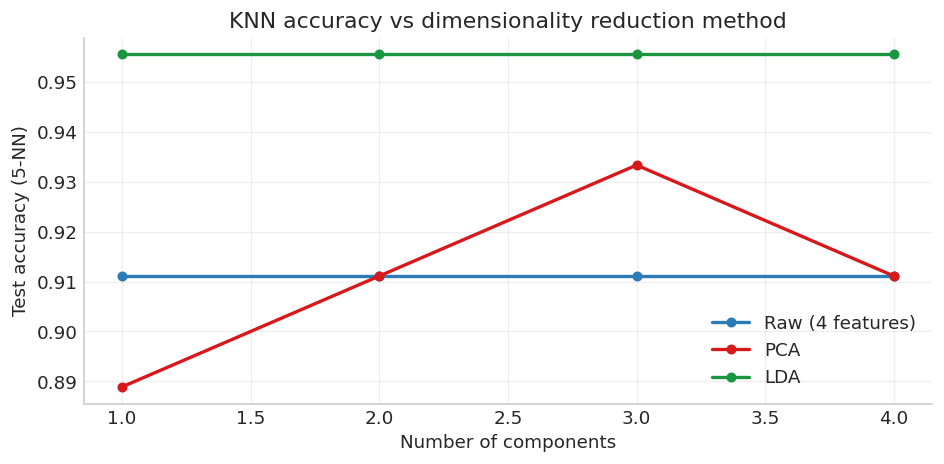

In [13]:
# --------------------------------------------------------------------------
# 8. Classification accuracy: raw features vs PCA vs LDA
# --------------------------------------------------------------------------
from sklearn.neighbors import KNeighborsClassifier

X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_std, y_iris, test_size=0.3, stratify=y_iris, random_state=RANDOM_STATE)

results = {}
k_range_comp = range(1, X_std.shape[1]+1)

for method_name, transformer in [
    ("Raw (4 features)", None),
    ("PCA", PCA(random_state=RANDOM_STATE)),
    ("LDA", LinearDiscriminantAnalysis()),
]:
    accs = []
    for k in k_range_comp:
        if transformer is None:
            Xtr, Xte = X_tr_i, X_te_i
        else:
            try:
                t = (PCA(n_components=k, random_state=RANDOM_STATE)
                     if "PCA" in method_name
                     else LinearDiscriminantAnalysis(n_components=min(k, len(np.unique(y_iris))-1)))
                Xtr = t.fit_transform(X_tr_i, y_tr_i)
                Xte = t.transform(X_te_i)
            except Exception:
                Xtr, Xte = X_tr_i[:, :k], X_te_i[:, :k]
        clf = KNeighborsClassifier(n_neighbors=5)
        clf.fit(Xtr, y_tr_i)
        accs.append(accuracy_score(y_te_i, clf.predict(Xte)))
    results[method_name] = accs

fig, ax = plt.subplots(figsize=(8, 4))
for (name, accs), color in zip(results.items(), COLORS):
    ax.plot(list(k_range_comp), accs, marker='o', color=color, lw=2,
            label=name, markersize=5)
ax.set_xlabel("Number of components"); ax.set_ylabel("Test accuracy (5-NN)")
ax.set_title("KNN accuracy vs dimensionality reduction method")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Підсумок

- **LDA** досягає найвищої точності вже при $k = 1$: LD1 максимально відокремлює класи, і навіть одновимірна проекція є достатньою для ефективної класифікації.
- **PCA** потребує 2–3 компонент для стабільно хорошої точності та поступово наближається до результатів на повному наборі ознак.
- Для датасету *Iris* всі методи досягають близьких результатів через відносну простоту задачі (лише 4 ознаки, умовно лінійно роздільні класи).
- **Практична рекомендація:** для задач класифікації з відомими мітками LDA практично завжди перевершує PCA, оскільки оптимізується саме під роздільність класів, а не під загальну дисперсію даних.